# Persistent (Co)homology of PFC Manifold Structure — Wake & Sleep

Tests whether PFC population activity lies on a low-dimensional **topological
manifold** (primarily a cyclic ring **S¹** reflecting the A→B→C→D→A task) and
whether it is **preserved during sleep**.

Heavy computation is done by `mFC_data/code/run_ph_batch.py` on SLURM (see
`sbatch_files/ph_pfc.sbatch` / `submit_ph_lec.sh`); this notebook **loads the
cached pickles and plots**. Companion of `cyclic_structure_analysis.py` (which
tests cyclic *geometry*, not *topology*).

**Pipeline:** timepoint population vectors → smooth + z-score + PCA → max-min
landmarks → ripser H0–H2 (Z/2, Z/3) → per-neuron circular-shift shuffle null →
DREiMac circular coordinate → related to behaviour; sleep done de novo **and** by
projection onto the wake manifold.

**PFC notes:** neuron counts vary per recday (1–117; recdays with <12 neurons are skipped) and there is **no head direction**, so the θ-vs-HD panel reads n/a. Sleep comes from joblib `binned_FR_dic_*` files with the same neurons as wake.

In [1]:
# --- setup ---
import os, sys, glob
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
sys.path.insert(0, os.path.abspath('.'))
import persistent_homology_analysis as ph; reload(ph)
import glm_analysis_v2 as glm
glm.apply_gridmaze_style()

# Point at the SLURM output dir; falls back to the smoke-test dir so the
# notebook runs before the full sweep has finished.
OUT_DIR = '../data/ph_outputs'
if not glob.glob(os.path.join(OUT_DIR, '*.pkl')):
    OUT_DIR = '../data/ph_outputs_smoketest'
SAVE_DIR = '../data/ph_outputs/figures'
SAVE_FIGS = False
# per-session figure loops: cap how many sessions to plot
# (the full sweep has 100s of sessions; set higher/None-slice to see more)
MAX_PLOT = 3
print('loading from', OUT_DIR)

loading from ../data/ph_outputs


## Load results + summary table

In [2]:
results = ph.load_ph_outputs(OUT_DIR)
print(f'{len(results)} result file(s)')
df = ph.summarise(results)
df

720 result file(s)


,stem,mouse_recday,state,n_neurons,n_points,H1_top,H1_ratio,H1_p,H2_top,H2_ratio,...,replay_coverage,replay_p_continuity,replay_continuity_ratio,net_revolutions,task_phase_R,task_phase_p,goal_progress_R,goal_progress_p,head_direction_R,head_direction_p
0,ab03_01092023_02092023__sleep_sb0,ab03_01092023_02092023,sleep,63,36514,0.783977,1.028646,0.079208,0.463323,1.041210,...,0.003274,0.004975,7.943756,0.010345,NaN,NaN,NaN,NaN,NaN,NaN
1,ab03_01092023_02092023__sleep_sb1,ab03_01092023_02092023,sleep,63,12089,1.029802,1.154697,0.009901,0.498726,1.109867,...,0.002242,0.004975,6.230629,0.005153,NaN,NaN,NaN,NaN,NaN,NaN
2,ab03_01092023_02092023__sleep_sb10,ab03_01092023_02092023,sleep,63,12188,0.823512,1.071356,0.069307,0.458874,1.059926,...,0.000032,0.004975,3.497781,0.000031,NaN,NaN,NaN,NaN,NaN,NaN
3,ab03_01092023_02092023__sleep_sb11,ab03_01092023_02092023,sleep,63,12319,1.063968,1.336350,0.009901,0.591093,1.092853,...,0.000979,0.004975,5.879587,0.004135,NaN,NaN,NaN,NaN,NaN,NaN
4,ab03_01092023_02092023__sleep_sb12,ab03_01092023_02092023,sleep,63,12219,0.794465,1.056829,0.079208,0.442075,1.042411,...,0.011479,0.004975,7.195721,0.000004,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,me11_12122021_13122021__wake_s1,me11_12122021_13122021,wake,12,9043,0.577915,1.037491,0.465347,0.298078,1.033373,...,NaN,NaN,NaN,NaN,0.050832,0.990010,0.026088,0.450549,NaN,NaN
580,me11_12122021_13122021__wake_s3,me11_12122021_13122021,wake,12,8580,0.674797,1.212809,0.138614,0.278395,1.013199,...,NaN,NaN,NaN,NaN,0.095270,0.135864,0.027986,0.625375,NaN,NaN
581,me11_12122021_13122021__wake_s5,me11_12122021_13122021,wake,12,6187,0.790685,1.208358,0.099010,0.288519,1.040522,...,NaN,NaN,NaN,NaN,0.158772,0.381618,0.056551,0.210789,NaN,NaN
582,me11_12122021_13122021__wake_s6,me11_12122021_13122021,wake,12,8441,0.564283,1.137988,0.564356,0.274011,1.010575,...,NaN,NaN,NaN,NaN,0.100929,0.526474,0.030366,0.263736,NaN,NaN


In [3]:
# split wake / sleep for convenience
wake  = {k: v for k, v in results.items() if v.get('state') == 'wake'}
sleep = {k: v for k, v in results.items() if v.get('state') == 'sleep'}
print(f'wake sessions: {len(wake)}   sleep boxes: {len(sleep)}')

wake sessions: 137   sleep boxes: 447


## Fig 1 — Persistence diagrams, barcodes & significance (per wake session)

A genuine ring shows **one** H1 bar far above the rest and above the shuffle
null; H2 stays at noise. Equal-length bars (ratio ≈ 1) = topological noise.

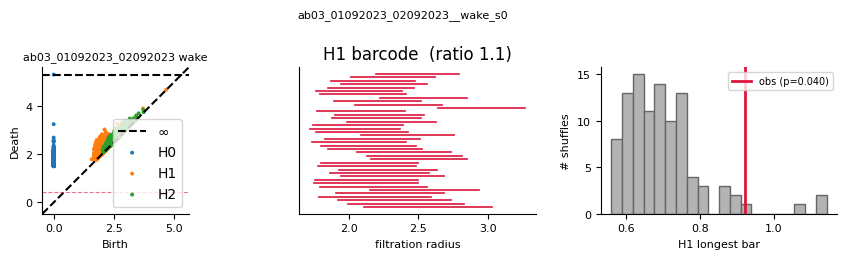

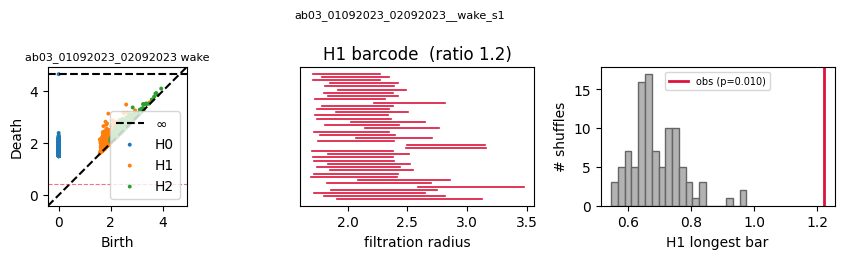

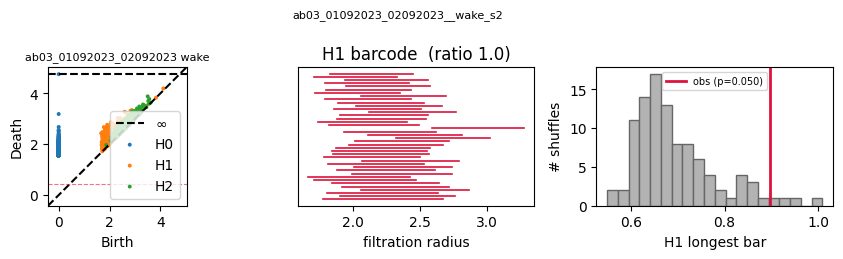

In [4]:
for stem, res in list(wake.items())[:MAX_PLOT]:
    fig, axes = plt.subplots(1, 3, figsize=(9, 2.6))
    ph.plot_persistence(res, ax=axes[0])
    ph.plot_barcode(res, dim=1, ax=axes[1])
    ph.plot_significance(res, dim=1, ax=axes[2])
    fig.suptitle(stem, fontsize=8); fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig1_persistence_'+stem, SAVE_DIR)
    plt.show()

## Fig 2 — Betti summary across sessions / mice

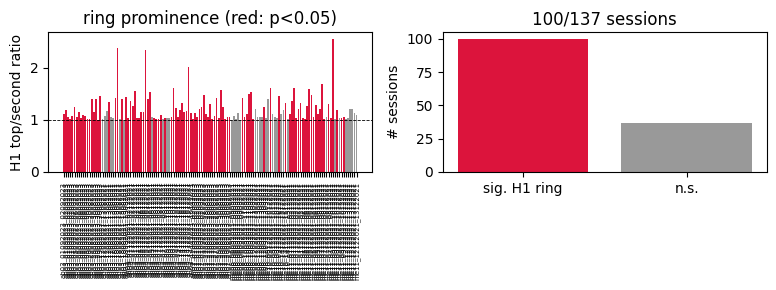

In [5]:
if len(df):
    wdf = df[df.state == 'wake'].reset_index(drop=True)
    fig, ax = plt.subplots(1, 2, figsize=(8, 3))
    x = np.arange(len(wdf))
    cols = ['crimson' if p < 0.05 else '0.6' for p in wdf['H1_p'].fillna(1)]
    ax[0].bar(x, wdf['H1_ratio'], color=cols)
    ax[0].axhline(1, ls='--', color='k', lw=0.6)
    ax[0].set_xticks(x); ax[0].set_xticklabels(wdf['mouse_recday'], rotation=90, fontsize=5)
    ax[0].set_ylabel('H1 top/second ratio'); ax[0].set_title('ring prominence (red: p<0.05)')
    n_sig = int((wdf['H1_p'] < 0.05).sum())
    ax[1].bar(['sig. H1 ring', 'n.s.'], [n_sig, len(wdf) - n_sig], color=['crimson', '0.6'])
    ax[1].set_ylabel('# sessions'); ax[1].set_title(f'{n_sig}/{len(wdf)} sessions')
    fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig2_betti_summary', SAVE_DIR)
    plt.show()

## Fig 3 — Circular coordinate vs behaviour

Does the decoded neural angle θ track the **circular task phase** (and goal
progress / head direction)? `R` = reflection-aware resultant length (1 = perfect,
~0 = chance); `p` from circular-shift shuffles.

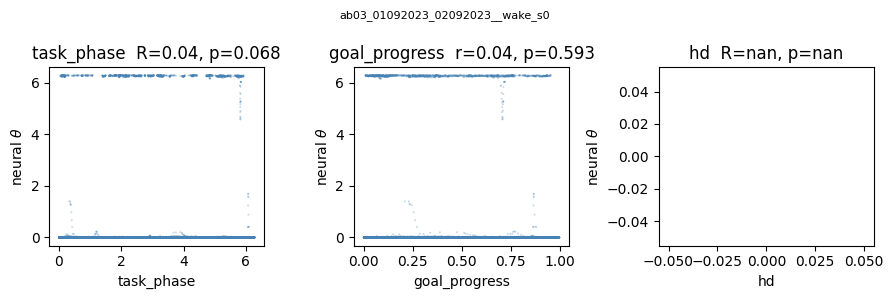

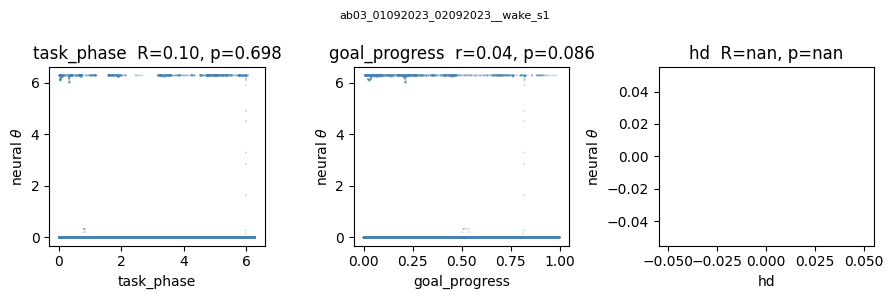

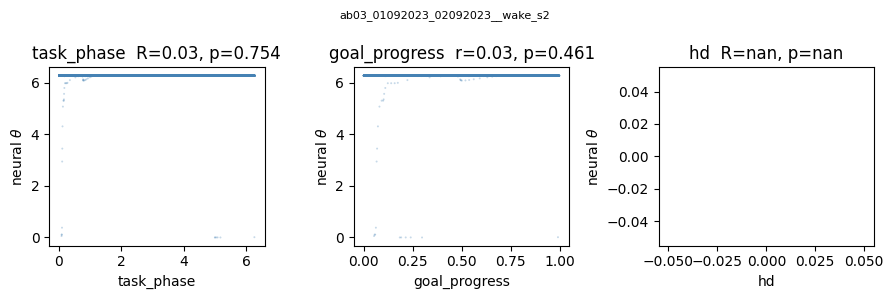

In [6]:
for stem, res in list(wake.items())[:MAX_PLOT]:
    if 'theta' not in res:
        continue
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    ph.plot_coord_vs_behaviour(res, 'task_phase',   ax=axes[0])
    ph.plot_coord_vs_behaviour(res, 'goal_progress', ax=axes[1], circular=False)
    ph.plot_coord_vs_behaviour(res, 'hd',           ax=axes[2])
    fig.suptitle(stem, fontsize=8); fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig3_coord_'+stem, SAVE_DIR)
    plt.show()

## Fig 4 — Manifold embedding (PCA cloud coloured by θ and task phase)

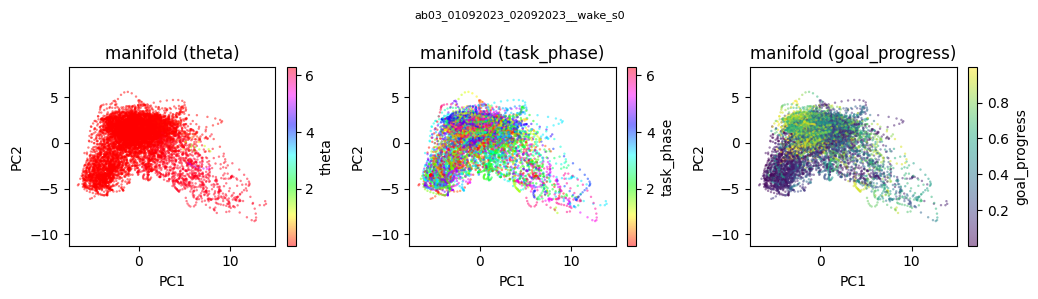

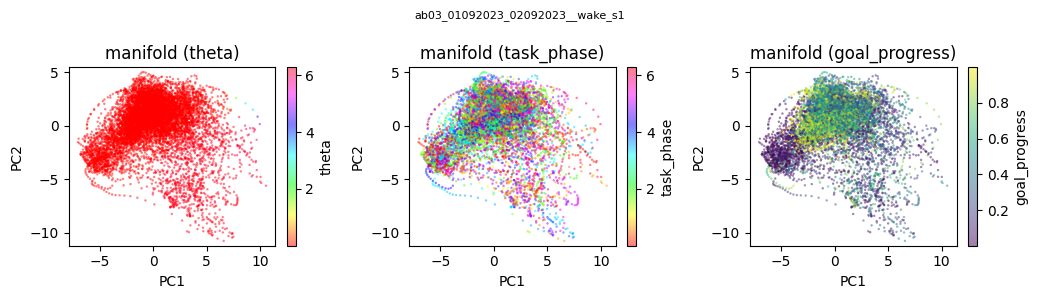

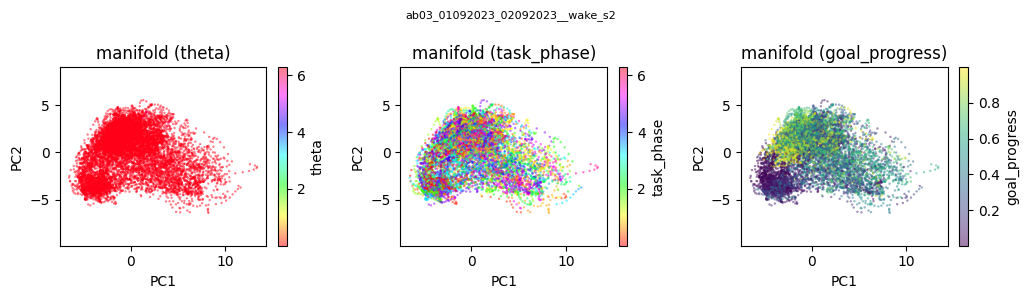

In [7]:
for stem, res in list(wake.items())[:MAX_PLOT]:
    if res.get('_X') is None:
        continue
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3))
    ph.plot_manifold(res, color_by='theta',         ax=axes[0])
    ph.plot_manifold(res, color_by='task_phase',    ax=axes[1])
    ph.plot_manifold(res, color_by='goal_progress', ax=axes[2])
    fig.suptitle(stem, fontsize=8); fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig4_manifold_'+stem, SAVE_DIR)
    plt.show()

## Fig 5 — Sleep: de novo topology + projection onto the wake ring

Left/middle: persistence + significance of the sleep cloud on its own.
Right: the wake circular coordinate decoded over sleep time — coherent cyclic
sweeps (high coherence, p small) indicate the manifold is traversed during
sleep (replay-like).

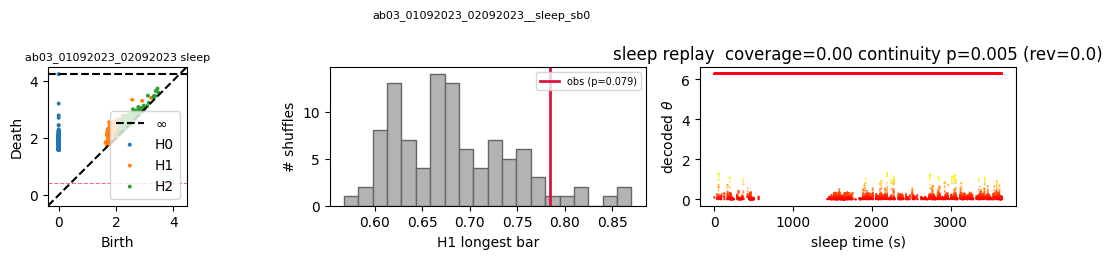

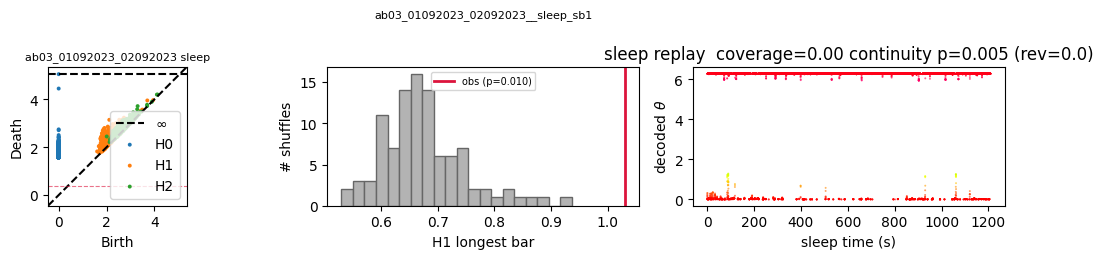

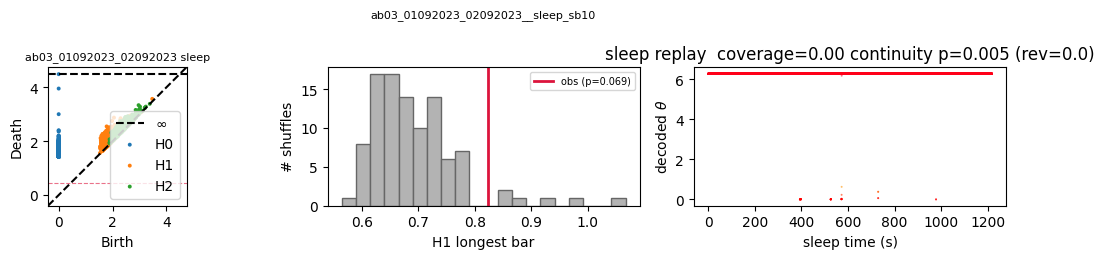

In [8]:
for stem, res in list(sleep.items())[:MAX_PLOT]:
    fig, axes = plt.subplots(1, 3, figsize=(11, 2.6))
    ph.plot_persistence(res, ax=axes[0])
    ph.plot_significance(res, dim=1, ax=axes[1])
    ph.plot_sleep_replay(res, ax=axes[2])
    fig.suptitle(stem, fontsize=8); fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig5_sleep_'+stem, SAVE_DIR)
    plt.show()

## Fig 6 — Wake vs sleep topology comparison

In [9]:
cols = ['mouse_recday', 'state', 'n_points', 'H1_top', 'H1_ratio', 'H1_p',
        'H2_top', 'H2_ratio']
extra = [c for c in ('task_phase_R', 'task_phase_p', 'replay_coverage', 'replay_p_continuity',
                     'net_revolutions') if c in df.columns]
df[cols + extra]

,mouse_recday,state,n_points,H1_top,H1_ratio,H1_p,H2_top,H2_ratio,task_phase_R,task_phase_p,replay_coverage,replay_p_continuity,net_revolutions
0,ab03_01092023_02092023,sleep,36514,0.783977,1.028646,0.079208,0.463323,1.041210,NaN,NaN,0.003274,0.004975,0.010345
1,ab03_01092023_02092023,sleep,12089,1.029802,1.154697,0.009901,0.498726,1.109867,NaN,NaN,0.002242,0.004975,0.005153
2,ab03_01092023_02092023,sleep,12188,0.823512,1.071356,0.069307,0.458874,1.059926,NaN,NaN,0.000032,0.004975,0.000031
3,ab03_01092023_02092023,sleep,12319,1.063968,1.336350,0.009901,0.591093,1.092853,NaN,NaN,0.000979,0.004975,0.004135
4,ab03_01092023_02092023,sleep,12219,0.794465,1.056829,0.079208,0.442075,1.042411,NaN,NaN,0.011479,0.004975,0.000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,me11_12122021_13122021,wake,9043,0.577915,1.037491,0.465347,0.298078,1.033373,0.050832,0.990010,NaN,NaN,NaN
580,me11_12122021_13122021,wake,8580,0.674797,1.212809,0.138614,0.278395,1.013199,0.095270,0.135864,NaN,NaN,NaN
581,me11_12122021_13122021,wake,6187,0.790685,1.208358,0.099010,0.288519,1.040522,0.158772,0.381618,NaN,NaN,NaN
582,me11_12122021_13122021,wake,8441,0.564283,1.137988,0.564356,0.274011,1.010575,0.100929,0.526474,NaN,NaN,NaN


## Diagnostic — smoothing sweep (live, one raw file)

The task cycle is slow (~tens of seconds), so the ring (if present) emerges only
once smoothing passes the fast spiking noise. This sweeps the smoothing kernel on
a single raw recording and reports the H1 prominence — handy for choosing
`smooth_sigma_bins` / `bin_ms`.

In [10]:
raw_file = '../data/Neuronal_activity/Awake/Neuron_raw_ah04_01122021_02122021_0.npy'
raw = np.load(raw_file, allow_pickle=True)
print(f'{"sigma_ms":>9} {"PC1-3var":>9} {"H1ratio":>8} {"H1top":>7}')
for sig in (2, 4, 8, 16, 32):
    cfg = ph.PHConfig(n_landmarks=600, coeff_fields=(2,), maxdim=1,
                      smooth_sigma_bins=sig, speed_filter_wake=False)
    X, _, model = ph.build_point_cloud(raw, cfg)
    s = ph.compute_persistence(X, cfg)['summary'][2][1]
    ev = model['pca'].explained_variance_ratio_[:3].sum()
    print(f'{sig*cfg.bin_ms:>9.0f} {ev:>9.2f} {s["gap_ratio"]:>8.2f} {s["top"]:>7.3f}')

 sigma_ms  PC1-3var  H1ratio   H1top


      200      0.16     1.14   0.942


      400      0.19     1.03   0.912


      800      0.24     1.09   1.169


     1600      0.27     1.00   1.517


     3200      0.29     1.11   3.164


## Fig 7 — Task-phase ring (trial-averaged) — the complementary test

Each point is one **task-phase bin** of the trial-averaged `Neurons_norm`
(360 = 4 states x 90 bins). Only 360 points, so **no landmarks / subsampling /
density trimming** — structurally immune to the outlier-arm artifact that made the
instantaneous clouds produce false H1 bars.

**Read `top/diam`, not H1.** The averaged trajectory is a *closed curve by
construction* (the task cycles A->B->C->D->A), so H1=1 is trivial. The
theoretically-calibrated criterion is `top_over_diameter` = H1 top bar / diameter:

| | top/diam | coverage |
|---|---|---|
| ideal circle (theory) | **0.87** | 1.0 |
| synthetic true S1 ring | **0.83** | 0.88 |
| synthetic ramp (open arc, no hole) | 0.15 | **0.70** &larr; coverage alone is NOT sufficient |
| synthetic pure noise | 0.08 | 0.01 |

Two traps this section documents: **coverage alone can't prove a ring** (an open
ramp scores 0.70), and **phase-smoothing is a trap** — it lifts *noise* to
top/diam 0.47-0.66, tracking the real data, so `phase_smooth_bins=0` is the
default and any increase demands recalibrating the noise control.

136 session rings


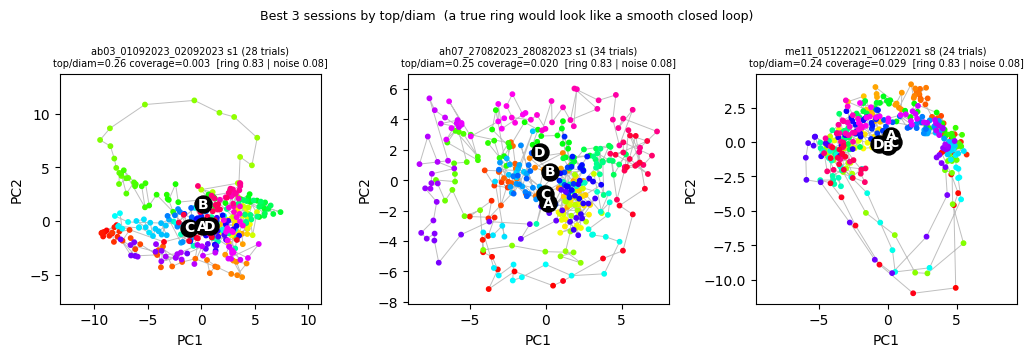

In [11]:
# Task-phase rings (written by run_taskphase_ring.py)
rings = {k: v for k, v in ph.load_ph_outputs(OUT_DIR).items() if v.get('state') == 'ring'}
print(f'{len(rings)} session rings')
if rings:
    best = sorted(rings.values(), key=lambda r: -r['geometry']['top_over_diameter'])[:3]
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))
    for ax, r in zip(axes, best):
        ph.plot_taskphase_ring(r, ax=ax)
    fig.suptitle('Best 3 sessions by top/diam  (a true ring would look like a smooth closed loop)',
                 fontsize=9)
    fig.tight_layout(); plt.show()

top/diam : median 0.114  max 0.259   [true ring 0.83 | noise 0.08]
ring-like (top/diam > 0.5): 0/136


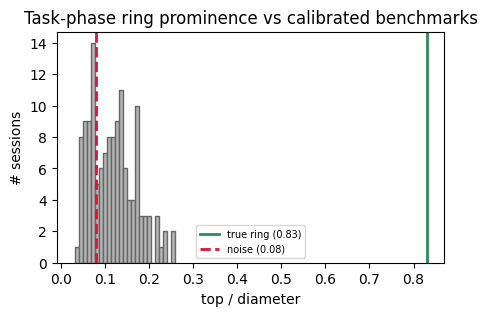

,mouse_recday,session,n_neurons,n_trials,top_over_diam,coverage,alignment,pc12_frac
1,ab03_01092023_02092023,1,63,28,0.258946,0.003236,0.003444,0.612511
66,ah07_27082023_28082023,1,80,34,0.254693,0.019689,0.021139,0.540082
118,me11_05122021_06122021,8,46,24,0.237033,0.028552,0.002635,0.617542
39,ah04_05122021_06122021,4,114,39,0.236780,0.060019,0.069221,0.499975
67,ah07_27082023_28082023,2,80,34,0.227892,0.012563,0.013502,0.527590
63,ah07_01092023_02092023,3,97,32,0.219091,0.015296,0.016300,0.571315
55,ah04_14122021_16122021,2,70,37,0.218889,0.056851,0.072716,0.550595
51,ah04_09122021_10122021,5,99,37,0.218843,0.003684,0.004948,0.585342
61,ah07_01092023_02092023,1,97,28,0.199736,0.016627,0.020648,0.560592
74,ah07_29082023_30082023,2,72,27,0.197674,0.032116,0.037526,0.547003


In [12]:
# cross-session summary vs the calibrated benchmarks
if rings:
    import pandas as pd
    df_ring = pd.DataFrame([dict(mouse_recday=r['mouse_recday'], session=r['session'],
                                 n_neurons=r['n_neurons'], n_trials=r['n_trials'],
                                 top_over_diam=r['geometry']['top_over_diameter'],
                                 coverage=r['coverage'], alignment=r['alignment'],
                                 pc12_frac=r['geometry']['pc12_frac'])
                            for r in rings.values()]).sort_values('top_over_diam', ascending=False)
    td = df_ring['top_over_diam'].values
    print(f"top/diam : median {np.median(td):.3f}  max {td.max():.3f}   [true ring 0.83 | noise 0.08]")
    print(f"ring-like (top/diam > 0.5): {(td > 0.5).sum()}/{len(td)}")
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.hist(td, bins=25, color='0.7', edgecolor='0.4')
    ax.axvline(0.83, color='seagreen', lw=2, label='true ring (0.83)')
    ax.axvline(0.08, color='crimson', lw=2, ls='--', label='noise (0.08)')
    ax.set_xlabel('top / diameter'); ax.set_ylabel('# sessions')
    ax.set_title('Task-phase ring prominence vs calibrated benchmarks'); ax.legend(fontsize=7)
    plt.show()
    display(df_ring.head(10))

---
### Interpretation guide
- **Significant H1 ring**: one H1 bar with high top/second ratio **and** `H1_p < 0.05`
  vs the per-neuron circular-shift null. The decoded θ should track `task_phase`
  (`task_phase_R` high, `p` small) for the ring to be the *task* ring.
- **Torus**: two long H1 bars **and** a long H2 bar (`H2_ratio ≫ 1`) — rerun the
  batch with the toroidal-coordinate path if this appears.
- **Sleep preservation / replay**: sleep θ(t) moves smoothly
  (`replay_p_continuity < 0.05`) **and** actually explores the ring
  (`replay_coverage` well above 0) ⇒ the wake manifold is
  traversed during sleep.
- A flat barcode (ratios ≈ 1, `H1_p` n.s.) is the honest **null result**: no
  low-dimensional ring in instantaneous activity at these settings.